# Análisis Exploratorio del Dataset Geoespacial de Barrios y Veredas de Medellín

Este notebook analiza el archivo GeoJSON `data/limite_barrio_vereda_cata.geojson`, que contiene los polígonos de los barrios y veredas del municipio de Medellín, agrupados por comunas.

**Objetivo:** Comprender la estructura del dataset antes de implementar el algoritmo de clasificación de coordenadas en barrios y comunas.

---

## 1. Importación de librerías

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga del archivo GeoJSON

In [2]:
RUTA_GEOJSON = 'data/limite_barrio_vereda_cata.geojson'

gdf = gpd.read_file(RUTA_GEOJSON)

print(f'Archivo cargado exitosamente.')
print(f'  • Número de features (barrios/veredas): {len(gdf)}')
print(f'  • Sistema de referencia de coordenadas (CRS): {gdf.crs}')
print(f'  • Columnas disponibles: {list(gdf.columns)}')

Archivo cargado exitosamente.
  • Número de features (barrios/veredas): 349
  • Sistema de referencia de coordenadas (CRS): EPSG:9377
  • Columnas disponibles: ['OBJECTID', 'comuna', 'barrio', 'codigo', 'nombre_barrio', 'indicador_ur', 'sector', 'nombre_comuna', 'fecha_sincronizacion', 'Shape_Length', 'Shape_Area', 'geometry']


## 3. Estructura del dataset

### 3.1 Primeras filas del GeoDataFrame

In [3]:
gdf.head()

,OBJECTID,comuna,barrio,codigo,nombre_barrio,indicador_ur,sector,nombre_comuna,fecha_sincronizacion,Shape_Length,Shape_Area,geometry
0,1,50,87,5087,Suburbano Potrera Miserenga,R,7,PALMITAS,1746152102000,10793.745904,1.112742e+06,"POLYGON ((4702200.304 2261423.185, 4702194.246..."
1,2,90,08,9008,Piedras Blancas,R,9,SANTA ELENA,1746152102000,28242.883995,1.173412e+07,"POLYGON ((4719822.945 2254827.749, 4719821.769..."
2,3,08,06,0806,Llanaditas,U,3,VILLA HERMOSA,1746152102000,3770.603451,2.638531e+05,"POLYGON ((4719157.189 2250063.198, 4719157.181..."
3,4,60,06,6006,La Cuchilla,R,7,SAN CRISTOBAL,1746152102000,5659.422464,6.306618e+05,"POLYGON ((4705777.892 2254965.265, 4705777.499..."
4,5,14,11,1411,Los Balsos No.1,U,5,EL POBLADO,1746152102000,6185.278317,1.426434e+06,"POLYGON ((4717311.158 2242869.355, 4717311.146..."


### 3.2 Tipos de datos y valores nulos

In [4]:
print('=== Tipos de datos ===')
print(gdf.dtypes)
print()
print('=== Valores nulos por columna ===')
print(gdf.isnull().sum())

=== Tipos de datos ===
OBJECTID                   int32
comuna                       str
barrio                       str
codigo                       str
nombre_barrio                str
indicador_ur                 str
sector                     int32
nombre_comuna                str
fecha_sincronizacion       int64
Shape_Length             float64
Shape_Area               float64
geometry                geometry
dtype: object

=== Valores nulos por columna ===
OBJECTID                0
comuna                  0
barrio                  0
codigo                  0
nombre_barrio           0
indicador_ur            4
sector                  0
nombre_comuna           0
fecha_sincronizacion    0
Shape_Length            0
Shape_Area              0
geometry                0
dtype: int64


### 3.3 Descripción estadística de columnas numéricas

In [5]:
gdf[['Shape_Length', 'Shape_Area', 'sector']].describe().round(2)

,Shape_Length,Shape_Area,sector
count,349.00,349.00,349.00
mean,4888.90,1079700.38,4.22
std,5350.97,2488714.35,2.51
min,257.37,2754.03,1.00
25%,2512.35,234712.33,2.00
50%,3220.97,371183.93,4.00
75%,4375.36,620400.53,6.00
max,38723.01,17107857.96,9.00


### 3.4 Descripción de campos clave

| Campo | Descripción |
|---|---|
| `OBJECTID` | Identificador único del registro |
| `comuna` | Código numérico de la comuna (como texto) |
| `barrio` | Código numérico del barrio dentro de la comuna |
| `codigo` | Código compuesto (comuna + barrio) |
| `nombre_barrio` | Nombre oficial del barrio o vereda |
| `nombre_comuna` | Nombre oficial de la comuna |
| `indicador_ur` | Clasificación: **U** = Urbano, **R** = Rural |
| `sector` | Agrupación geográfica de comunas (1–9) |
| `Shape_Length` | Perímetro del polígono en metros (EPSG:9377) |
| `Shape_Area` | Área del polígono en metros cuadrados (EPSG:9377) |
| `geometry` | Geometría del polígono (Polygon o MultiPolygon) |

## 4. Análisis del Sistema de Referencia de Coordenadas (CRS)

El archivo usa **EPSG:9377** (Magna-Sirgas / Origen Unico), el sistema oficial de Colombia desde 2020. Las coordenadas están expresadas en metros, **no** en grados de latitud/longitud.

In [6]:
print('CRS original del dataset:')
print(f'  Nombre: {gdf.crs.name}')
print(f'  EPSG:   {gdf.crs.to_epsg()}')
print(f'  Unidad: {gdf.crs.axis_info[0].unit_name}')
print()
print('Coordenadas de la primera geometría (muestra):')
first_coords = list(gdf.geometry.iloc[0].exterior.coords)[:3]
for c in first_coords:
    print(f'  X={c[0]:.2f} m,  Y={c[1]:.2f} m')
print()
print('► Para clasificación de puntos geocodificados (WGS84/EPSG:4326),')
print('  será necesario reproyectar este dataset a EPSG:4326 usando gdf.to_crs(4326).')

CRS original del dataset:
  Nombre: MAGNA-SIRGAS 2018 / Origen-Nacional
  EPSG:   9377
  Unidad: metre

Coordenadas de la primera geometría (muestra):
  X=4702200.30 m,  Y=2261423.19 m
  X=4702194.25 m,  Y=2261431.42 m
  X=4702184.93 m,  Y=2261443.74 m

► Para clasificación de puntos geocodificados (WGS84/EPSG:4326),
  será necesario reproyectar este dataset a EPSG:4326 usando gdf.to_crs(4326).


## 5. Análisis de Comunas

### 5.1 Número de barrios/veredas por comuna

In [7]:
barrios_por_comuna = (
    gdf.groupby('nombre_comuna')
    .size()
    .reset_index(name='num_barrios')
    .sort_values('num_barrios', ascending=False)
)

print(f'Total de comunas: {barrios_por_comuna.shape[0]}')
print()
print(barrios_por_comuna.to_string(index=False))

Total de comunas: 21

       nombre_comuna  num_barrios
       SAN CRISTOBAL           26
             ROBLEDO           24
         SANTA ELENA           24
          EL POBLADO           22
               BELEN           21
       LA CANDELARIA           20
          SAN JAVIER           19
       VILLA HERMOSA           18
            CASTILLA           18
            ARANJUEZ           17
        BUENOS AIRES           17
            LAURELES           17
            MANRIQUE           15
          LA AMERICA           13
           ALTAVISTA           12
     DOCE DE OCTUBRE           12
             POPULAR           12
SAN ANTONIO DE PRADO           11
            PALMITAS           11
          SANTA CRUZ           11
            GUAYABAL            9


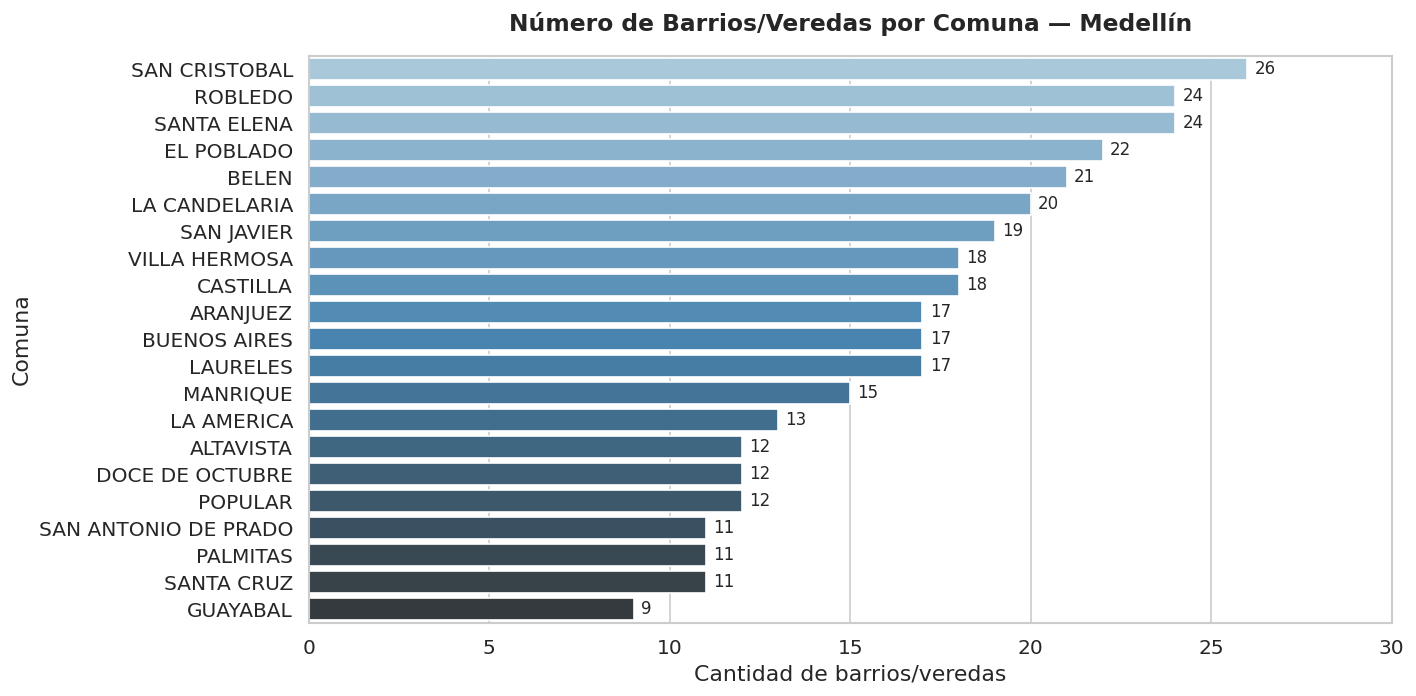

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=barrios_por_comuna,
    x='num_barrios',
    y='nombre_comuna',
    palette='Blues_d',
    ax=ax
)

for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        int(bar.get_width()),
        va='center', ha='left', fontsize=10
    )

ax.set_title('Número de Barrios/Veredas por Comuna — Medellín', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Cantidad de barrios/veredas')
ax.set_ylabel('Comuna')
ax.set_xlim(0, barrios_por_comuna['num_barrios'].max() + 4)
plt.tight_layout()
plt.show()

### 5.2 Distribución de sectores y sus comunas

Medellín agrupa sus comunas en **9 sectores** geográficos:

In [9]:
sector_comunas = (
    gdf[['sector', 'nombre_comuna']]
    .drop_duplicates()
    .sort_values(['sector', 'nombre_comuna'])
)

print('Sector → Comunas:')
for sector, grupo in sector_comunas.groupby('sector'):
    comunas_lista = ', '.join(grupo['nombre_comuna'].tolist())
    print(f'  Sector {sector}: {comunas_lista}')

Sector → Comunas:
  Sector 1: ARANJUEZ, MANRIQUE, POPULAR, SANTA CRUZ
  Sector 2: CASTILLA, DOCE DE OCTUBRE, ROBLEDO
  Sector 3: BUENOS AIRES, LA CANDELARIA, VILLA HERMOSA
  Sector 4: LA AMERICA, LAURELES, SAN JAVIER
  Sector 5: EL POBLADO
  Sector 6: BELEN, GUAYABAL
  Sector 7: PALMITAS, SAN CRISTOBAL
  Sector 8: ALTAVISTA, SAN ANTONIO DE PRADO
  Sector 9: SANTA ELENA


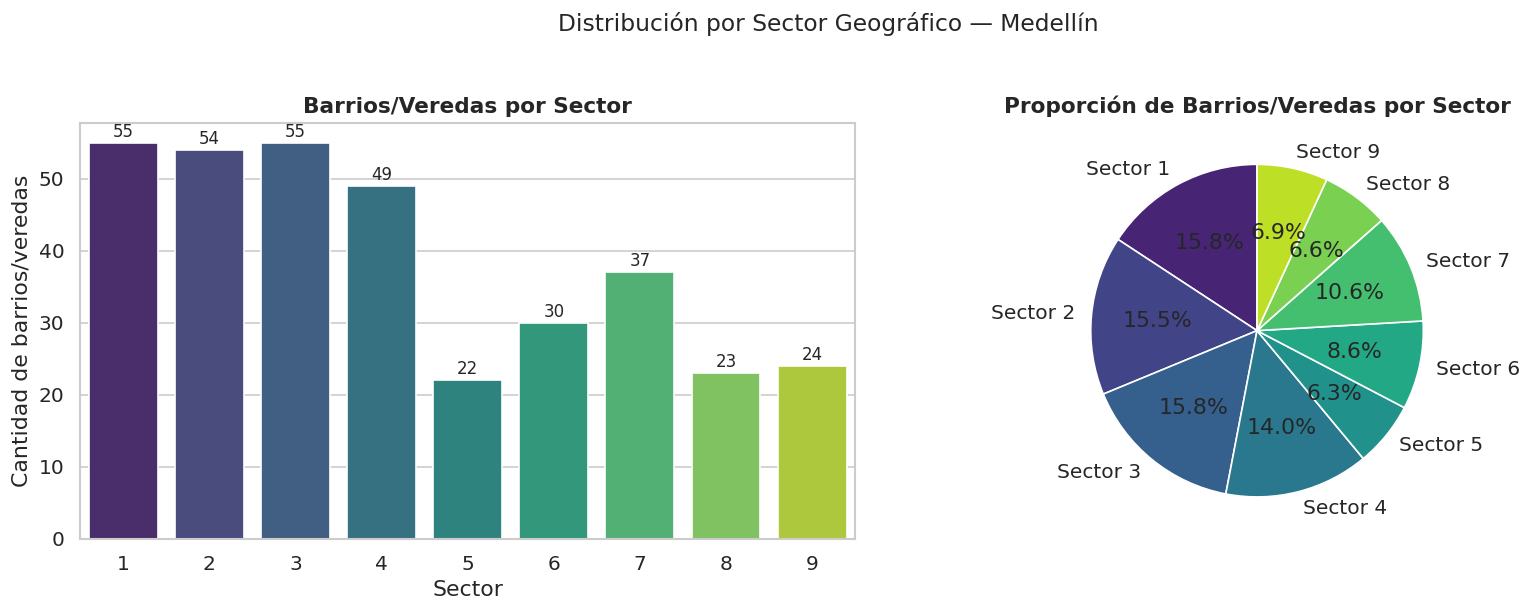

In [10]:
barrios_por_sector = (
    gdf.groupby('sector')
    .size()
    .reset_index(name='num_barrios')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot de barrios por sector
sns.barplot(
    data=barrios_por_sector,
    x='sector',
    y='num_barrios',
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('Barrios/Veredas por Sector', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sector')
axes[0].set_ylabel('Cantidad de barrios/veredas')
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        int(bar.get_height()),
        ha='center', va='bottom', fontsize=10
    )

# Pie chart de distribución por sector
axes[1].pie(
    barrios_por_sector['num_barrios'],
    labels=[f'Sector {s}' for s in barrios_por_sector['sector']],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('viridis', len(barrios_por_sector))
)
axes[1].set_title('Proporción de Barrios/Veredas por Sector', fontsize=13, fontweight='bold')

plt.suptitle('Distribución por Sector Geográfico — Medellín', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Clasificación Urbano / Rural

El campo `indicador_ur` diferencia entre zonas urbanas (**U**) y rurales (**R**). Algunos registros tienen valor nulo.

In [11]:
conteo_ur = gdf['indicador_ur'].value_counts(dropna=False).reset_index()
conteo_ur.columns = ['indicador', 'cantidad']
conteo_ur['etiqueta'] = conteo_ur['indicador'].map({'U': 'Urbano', 'R': 'Rural'}).fillna('Sin clasificar')

print('Clasificación Urbano / Rural:')
print(conteo_ur.to_string(index=False))
print()
total = conteo_ur['cantidad'].sum()
for _, row in conteo_ur.iterrows():
    pct = row['cantidad'] / total * 100
    print(f"  {row['etiqueta']}: {row['cantidad']} ({pct:.1f}%)")

Clasificación Urbano / Rural:
indicador  cantidad       etiqueta
        U       267         Urbano
        R        78          Rural
      NaN         4 Sin clasificar

  Urbano: 267 (76.5%)
  Rural: 78 (22.3%)
  Sin clasificar: 4 (1.1%)


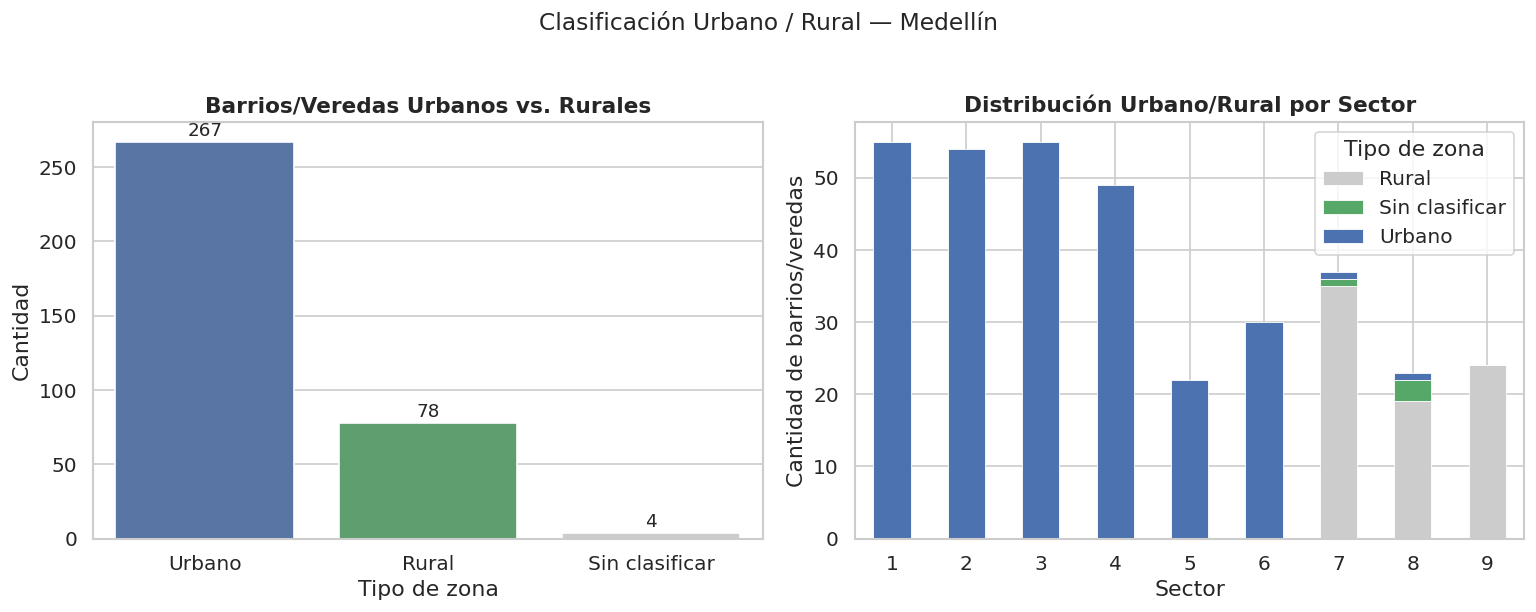

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barplot
colores = {'Urbano': '#4C72B0', 'Rural': '#55A868', 'Sin clasificar': '#CCCCCC'}
palette = [colores[e] for e in conteo_ur['etiqueta']]

sns.barplot(
    data=conteo_ur,
    x='etiqueta',
    y='cantidad',
    palette=palette,
    ax=axes[0]
)
axes[0].set_title('Barrios/Veredas Urbanos vs. Rurales', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tipo de zona')
axes[0].set_ylabel('Cantidad')
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        int(bar.get_height()),
        ha='center', va='bottom', fontsize=11
    )

# Distribución urbano/rural por sector (stacked)
pivot_ur = (
    gdf.assign(tipo=gdf['indicador_ur'].map({'U': 'Urbano', 'R': 'Rural'}).fillna('Sin clasificar'))
    .groupby(['sector', 'tipo'])
    .size()
    .unstack(fill_value=0)
)

pivot_ur.plot(
    kind='bar',
    stacked=True,
    color=['#CCCCCC', '#55A868', '#4C72B0'],
    ax=axes[1],
    edgecolor='white',
    linewidth=0.5
)
axes[1].set_title('Distribución Urbano/Rural por Sector', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sector')
axes[1].set_ylabel('Cantidad de barrios/veredas')
axes[1].legend(title='Tipo de zona', loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Clasificación Urbano / Rural — Medellín', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Análisis de Área de los Polígonos

El campo `Shape_Area` contiene el área de cada polígono en **metros cuadrados** (sistema EPSG:9377).

In [13]:
gdf['area_km2'] = gdf['Shape_Area'] / 1_000_000  # Convertir a km²

print('Estadísticas de área (km²):')
stats = gdf['area_km2'].describe()
print(f"  Mínimo:    {stats['min']:.4f} km²")
print(f"  Máximo:    {stats['max']:.4f} km²")
print(f"  Media:     {stats['mean']:.4f} km²")
print(f"  Mediana:   {gdf['area_km2'].median():.4f} km²")
print(f"  Desv. std: {stats['std']:.4f} km²")
print()
print('Los 5 barrios/veredas más grandes:')
print(gdf[['nombre_barrio', 'nombre_comuna', 'indicador_ur', 'area_km2']]
      .nlargest(5, 'area_km2')
      .to_string(index=False))
print()
print('Los 5 barrios/veredas más pequeños:')
print(gdf[['nombre_barrio', 'nombre_comuna', 'indicador_ur', 'area_km2']]
      .nsmallest(5, 'area_km2')
      .to_string(index=False))

Estadísticas de área (km²):
  Mínimo:    0.0028 km²
  Máximo:    17.1079 km²
  Media:     1.0797 km²
  Mediana:   0.3712 km²
  Desv. std: 2.4887 km²

Los 5 barrios/veredas más grandes:
           nombre_barrio        nombre_comuna indicador_ur  area_km2
            El Astillero SAN ANTONIO DE PRADO            R 17.107858
              La Frisola             PALMITAS            R 16.665901
 Piedras Blancas Represa          SANTA ELENA            R 15.287304
              Yarumalito SAN ANTONIO DE PRADO            R 14.826377
Altavista Sector Central            ALTAVISTA            R 13.281671

Los 5 barrios/veredas más pequeños:
        nombre_barrio   nombre_comuna indicador_ur  area_km2
Suburbano Aguas Frias       ALTAVISTA            R  0.002754
       Aldea Pablo VI         POPULAR            U  0.055609
        Ocho de Marzo    BUENOS AIRES            U  0.056605
     Mirador del Doce DOCE DE OCTUBRE            U  0.060613
             Pajarito   SAN CRISTOBAL            R  0.06273

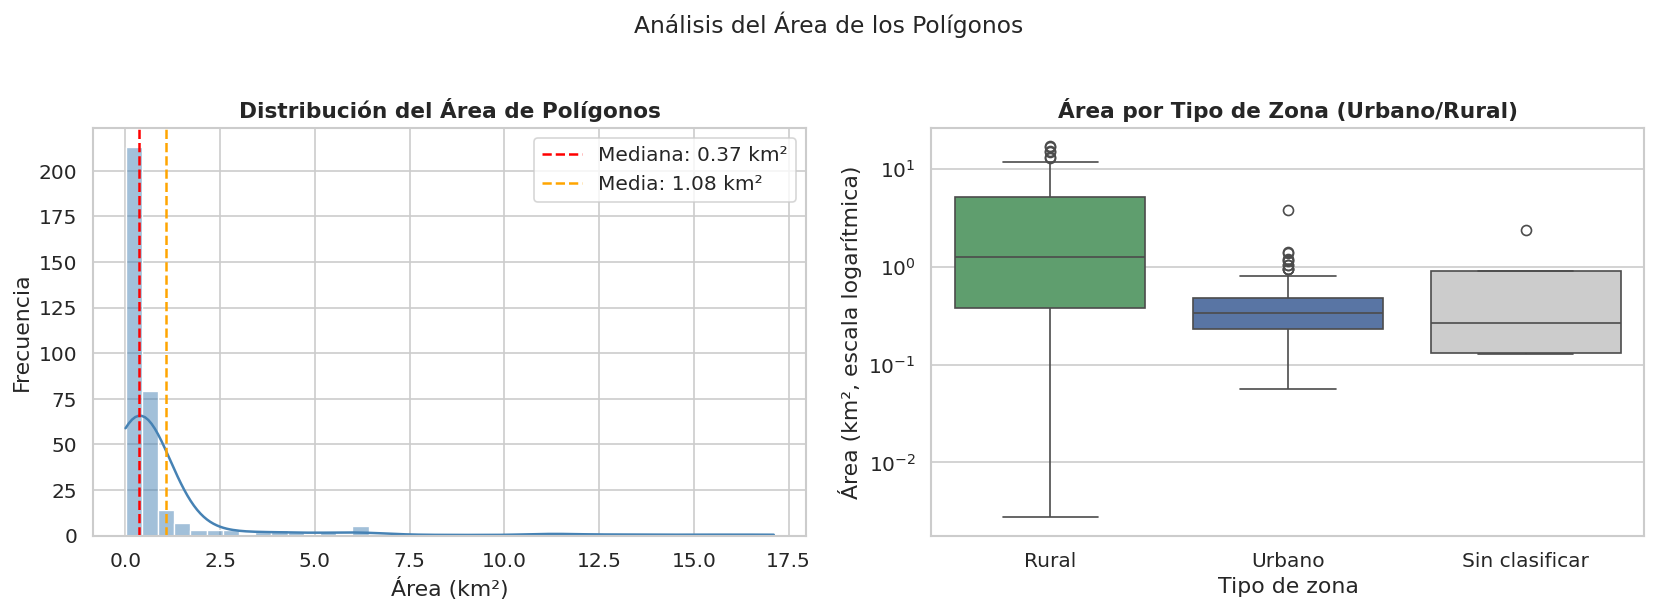

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de distribución de áreas (con transformación log)
sns.histplot(
    data=gdf,
    x='area_km2',
    bins=40,
    kde=True,
    color='steelblue',
    ax=axes[0]
)
axes[0].set_title('Distribución del Área de Polígonos', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Área (km²)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(gdf['area_km2'].median(), color='red', linestyle='--', label=f"Mediana: {gdf['area_km2'].median():.2f} km²")
axes[0].axvline(gdf['area_km2'].mean(), color='orange', linestyle='--', label=f"Media: {gdf['area_km2'].mean():.2f} km²")
axes[0].legend()

# Boxplot de área por tipo de zona (urbana/rural)
gdf_ur = gdf.assign(tipo=gdf['indicador_ur'].map({'U': 'Urbano', 'R': 'Rural'}).fillna('Sin clasificar'))
sns.boxplot(
    data=gdf_ur,
    x='tipo',
    y='area_km2',
    palette={'Urbano': '#4C72B0', 'Rural': '#55A868', 'Sin clasificar': '#CCCCCC'},
    ax=axes[1]
)
axes[1].set_title('Área por Tipo de Zona (Urbano/Rural)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tipo de zona')
axes[1].set_ylabel('Área (km²)')
axes[1].set_yscale('log')
axes[1].set_ylabel('Área (km², escala logarítmica)')

plt.suptitle('Análisis del Área de los Polígonos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

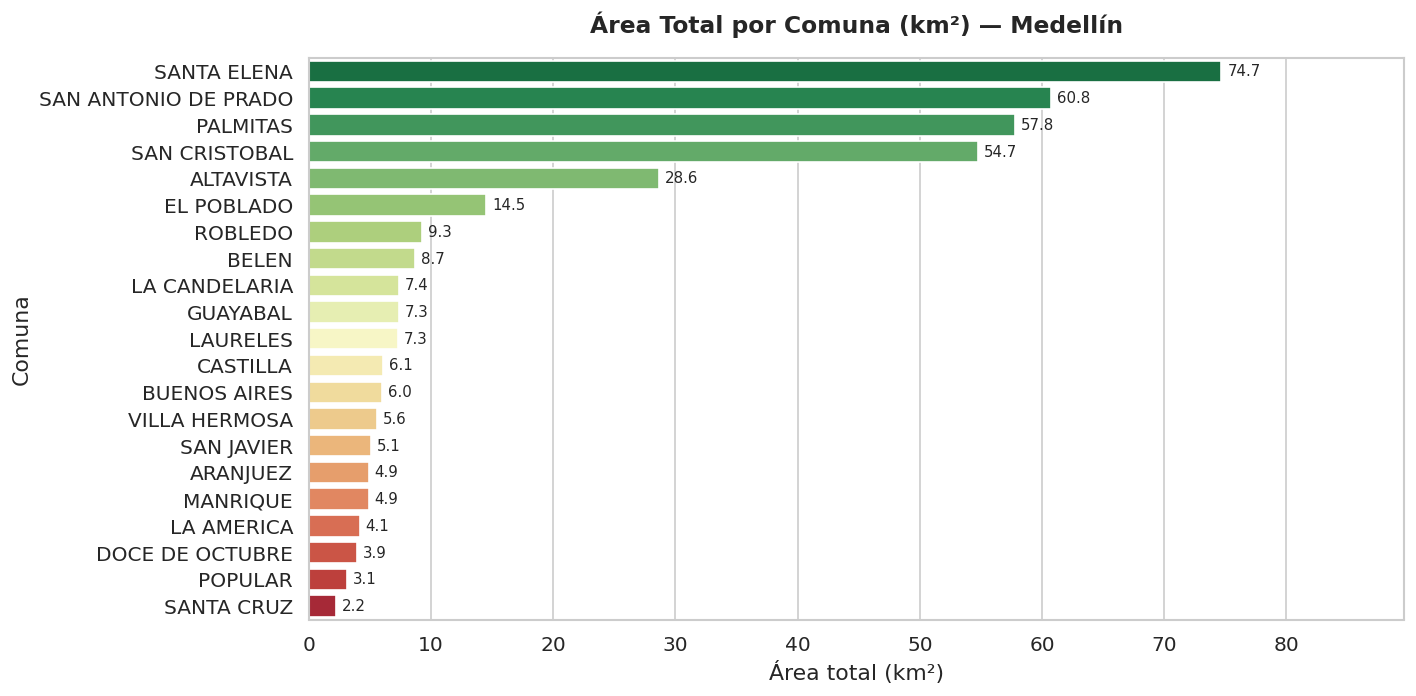

In [15]:
# Área total por comuna
area_por_comuna = (
    gdf.groupby('nombre_comuna')['area_km2']
    .sum()
    .reset_index(name='area_total_km2')
    .sort_values('area_total_km2', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))

palette_comunas = sns.color_palette(
    'RdYlGn_r',
    n_colors=len(area_por_comuna)
)

sns.barplot(
    data=area_por_comuna,
    x='area_total_km2',
    y='nombre_comuna',
    palette=palette_comunas,
    ax=ax
)

for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.1f}',
        va='center', ha='left', fontsize=9
    )

ax.set_title('Área Total por Comuna (km²) — Medellín', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Área total (km²)')
ax.set_ylabel('Comuna')
ax.set_xlim(0, area_por_comuna['area_total_km2'].max() + 15)
plt.tight_layout()
plt.show()

## 8. Mapa de Calor: Barrios por Sector y Tipo de Zona

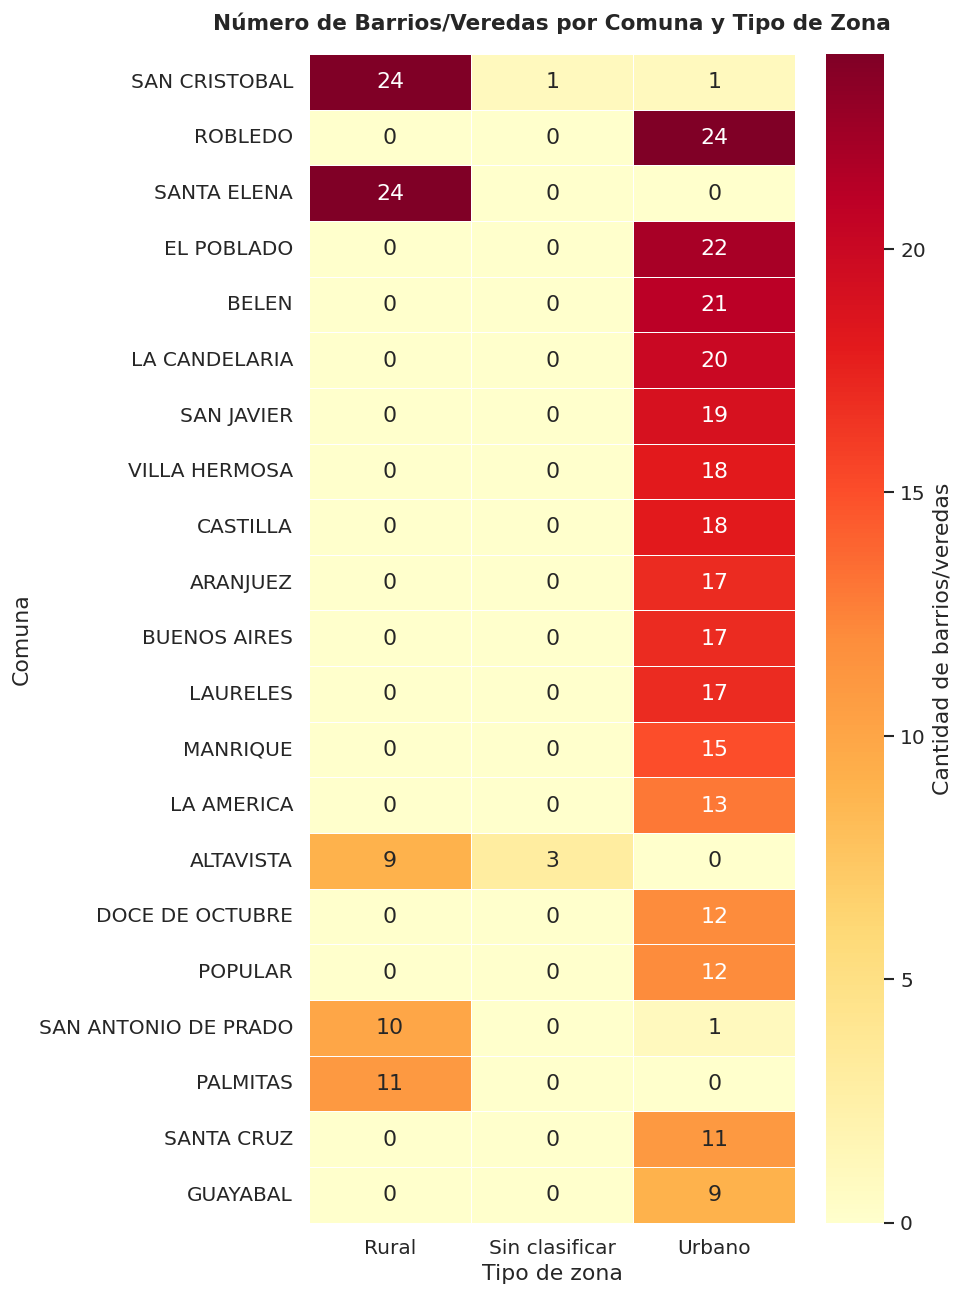

In [16]:
gdf_ur2 = gdf.assign(tipo=gdf['indicador_ur'].map({'U': 'Urbano', 'R': 'Rural'}).fillna('Sin clasificar'))

heatmap_data = (
    gdf_ur2.groupby(['nombre_comuna', 'tipo'])
    .size()
    .unstack(fill_value=0)
    .reindex(barrios_por_comuna['nombre_comuna'].tolist())
)

fig, ax = plt.subplots(figsize=(8, 11))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Cantidad de barrios/veredas'},
    ax=ax
)

ax.set_title('Número de Barrios/Veredas por Comuna y Tipo de Zona', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Tipo de zona')
ax.set_ylabel('Comuna')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

## 9. Análisis de Tipos de Geometría

In [17]:
gdf['tipo_geometria'] = gdf.geometry.geom_type

conteo_geom = gdf['tipo_geometria'].value_counts().reset_index()
conteo_geom.columns = ['tipo_geometria', 'cantidad']

print('Tipos de geometría presentes en el dataset:')
print(conteo_geom.to_string(index=False))
print()
print('Polígonos compuestos (MultiPolygon) — corresponden a barrios/veredas discontinuos:')
multipolygons = gdf[gdf['tipo_geometria'] == 'MultiPolygon'][['nombre_barrio', 'nombre_comuna', 'indicador_ur']]
print(multipolygons.to_string(index=False))

Tipos de geometría presentes en el dataset:
tipo_geometria  cantidad
       Polygon       338
  MultiPolygon        11

Polígonos compuestos (MultiPolygon) — corresponden a barrios/veredas discontinuos:
              nombre_barrio        nombre_comuna indicador_ur
                    El Plan          SANTA ELENA            R
         Trece de Noviembre        VILLA HERMOSA            U
       Suburbano Matasano 2          SANTA ELENA            R
          Potrera Miserenga             PALMITAS            R
         Suburbano Palmitas             PALMITAS            R
Area De Expansion Altavista            ALTAVISTA          NaN
         Suburbano El Cerro          SANTA ELENA            R
               El Astillero SAN ANTONIO DE PRADO            R
                    La Loma        SAN CRISTOBAL            R
         Suburbano El Llano          SANTA ELENA            R
                Aguas Frias            ALTAVISTA            R


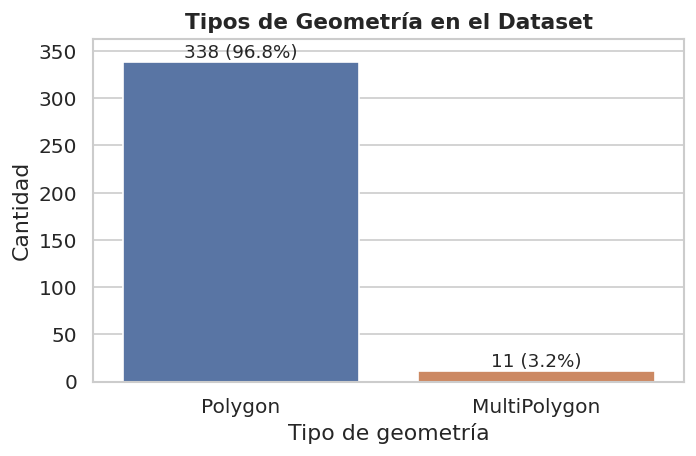

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(
    data=conteo_geom,
    x='tipo_geometria',
    y='cantidad',
    palette=['#4C72B0', '#DD8452'],
    ax=ax
)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{int(bar.get_height())} ({int(bar.get_height())/len(gdf)*100:.1f}%)',
        ha='center', va='bottom', fontsize=11
    )

ax.set_title('Tipos de Geometría en el Dataset', fontsize=13, fontweight='bold')
ax.set_xlabel('Tipo de geometría')
ax.set_ylabel('Cantidad')
ax.set_ylim(0, conteo_geom['cantidad'].max() + 25)
plt.tight_layout()
plt.show()

## 10. Visualización Geográfica de los Polígonos

Reproyección a **EPSG:4326** (WGS84) para visualizar sobre coordenadas geográficas estándar.

In [19]:
gdf_wgs84 = gdf.to_crs(epsg=4326)

print(f'CRS original:      EPSG:{gdf.crs.to_epsg()} ({gdf.crs.name})')
print(f'CRS reproyectado:  EPSG:{gdf_wgs84.crs.to_epsg()} ({gdf_wgs84.crs.name})')
print()

bounds = gdf_wgs84.total_bounds  # [minx, miny, maxx, maxy]
print('Bounding box del dataset (WGS84):')
print(f'  Longitud: {bounds[0]:.5f}° a {bounds[2]:.5f}°')
print(f'  Latitud:  {bounds[1]:.5f}° a {bounds[3]:.5f}°')

CRS original:      EPSG:9377 (MAGNA-SIRGAS 2018 / Origen-Nacional)
CRS reproyectado:  EPSG:4326 (WGS 84)

Bounding box del dataset (WGS84):
  Longitud: -75.71931° a -75.47185°
  Latitud:  6.16290° a 6.37487°


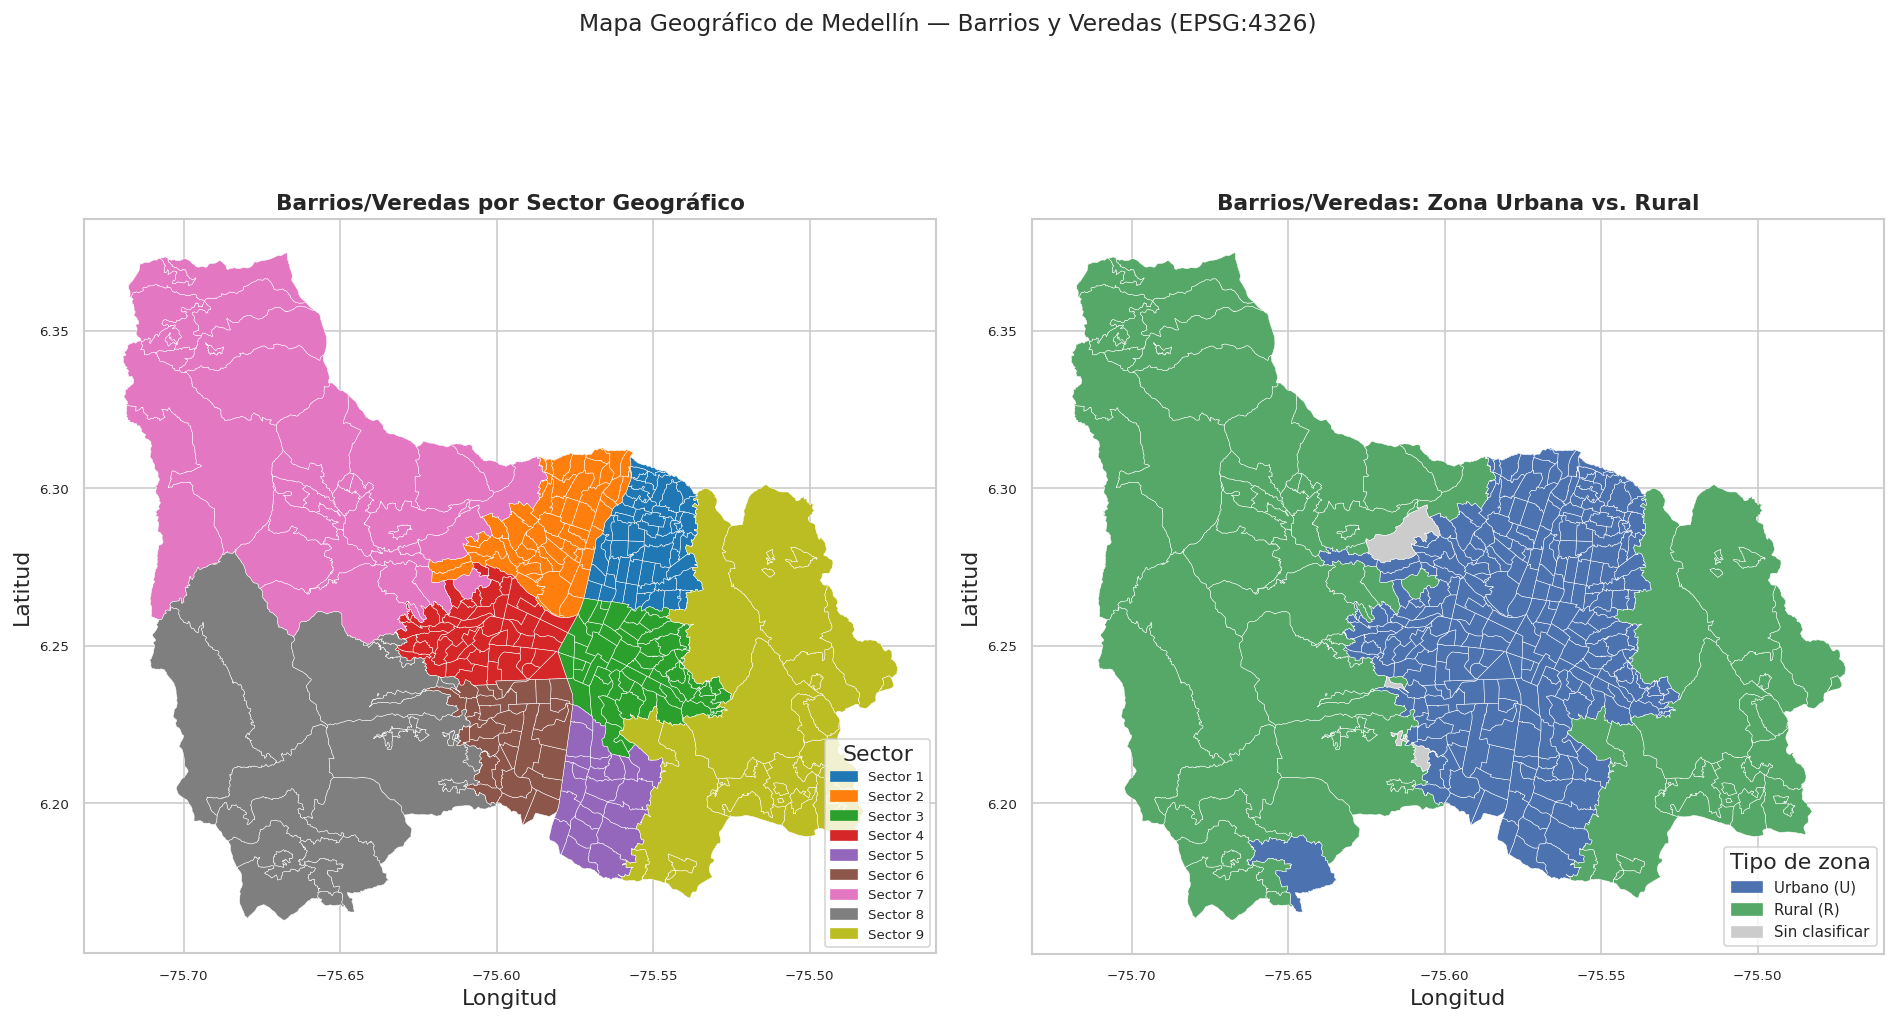

In [20]:
# Asignar color por sector para el mapa
n_sectores = gdf_wgs84['sector'].nunique()
colores_sector = dict(zip(
    sorted(gdf_wgs84['sector'].unique()),
    sns.color_palette('tab10', n_sectores)
))
gdf_wgs84['color_sector'] = gdf_wgs84['sector'].map(colores_sector)

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Mapa 1: coloreado por sector
for sector, color in colores_sector.items():
    subset = gdf_wgs84[gdf_wgs84['sector'] == sector]
    subset.plot(ax=axes[0], color=color, edgecolor='white', linewidth=0.3)

leyenda_sector = [
    mpatches.Patch(color=c, label=f'Sector {s}')
    for s, c in colores_sector.items()
]
axes[0].legend(handles=leyenda_sector, loc='lower right', fontsize=8, title='Sector')
axes[0].set_title('Barrios/Veredas por Sector Geográfico', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')
axes[0].tick_params(labelsize=8)

# Mapa 2: coloreado por tipo de zona
colores_ur = {'U': '#4C72B0', 'R': '#55A868', None: '#CCCCCC'}
for tipo, color in colores_ur.items():
    subset = gdf_wgs84[gdf_wgs84['indicador_ur'] == tipo] if tipo else gdf_wgs84[gdf_wgs84['indicador_ur'].isnull()]
    if not subset.empty:
        subset.plot(ax=axes[1], color=color, edgecolor='white', linewidth=0.3)

leyenda_ur = [
    mpatches.Patch(color='#4C72B0', label='Urbano (U)'),
    mpatches.Patch(color='#55A868', label='Rural (R)'),
    mpatches.Patch(color='#CCCCCC', label='Sin clasificar'),
]
axes[1].legend(handles=leyenda_ur, loc='lower right', fontsize=9, title='Tipo de zona')
axes[1].set_title('Barrios/Veredas: Zona Urbana vs. Rural', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')
axes[1].tick_params(labelsize=8)

plt.suptitle('Mapa Geográfico de Medellín — Barrios y Veredas (EPSG:4326)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 11. Conclusiones del Análisis

### Hallazgos clave

| Aspecto | Detalle |
|---|---|
| **Total de features** | 349 barrios/veredas |
| **Comunas** | 21 comunas |
| **Sectores** | 9 sectores geográficos |
| **CRS original** | EPSG:9377 (Magna-Sirgas / Origen Único) |
| **Geometría** | 338 Polygon + 11 MultiPolygon |
| **Zonas urbanas** | 267 (76.5%) |
| **Zonas rurales** | 78 (22.4%) |
| **Sin clasificar** | 4 (1.1%) |
| **Valores nulos** | Solo `indicador_ur` tiene 4 nulos |

### Consideraciones para el algoritmo de clasificación

1. **Reproyección obligatoria:** El dataset usa EPSG:9377 (metros), pero las coordenadas geocodificadas estarán en EPSG:4326 (grados). Antes de cualquier operación espacial, se debe ejecutar `gdf.to_crs(epsg=4326)`.

2. **MultiPolygon:** 11 features tienen geometría `MultiPolygon` (barrios/veredas con territorios discontinuos). La operación `sjoin` de geopandas maneja esto automáticamente sin tratamiento especial.

3. **Valores nulos en `indicador_ur`:** 4 features sin clasificación urbano/rural. No afectan la clasificación espacial, pero deben considerarse en reportes.

4. **Alta variabilidad de área:** La distribución de áreas es muy asimétrica (media >> mediana), dominada por las grandes veredas rurales de sectores 7, 8 y 9. Esto justifica el uso de Point-in-Polygon en lugar de centroide + 1-NN.

5. **Columnas a usar en la clasificación:**
   - `nombre_barrio`: nombre del barrio o vereda
   - `nombre_comuna`: nombre de la comuna
   - `codigo`: código compuesto (comuna + barrio)
   - `indicador_ur`: tipo de zona (U/R)
   - `sector`: sector geográfico
   - `geometry`: polígono para el spatial join